In [1]:
# Imports
import os
import sys
# ----File Stitching----
# If in results_cnn folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "results_cnn":
    os.chdir('..')
# If a file is in /data_prep_viz/prep/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'data_prep_viz/prep'))

/Users/sophiekim/Desktop/2_research/MamalakisResearch
Sophie Kim recognized as user.
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


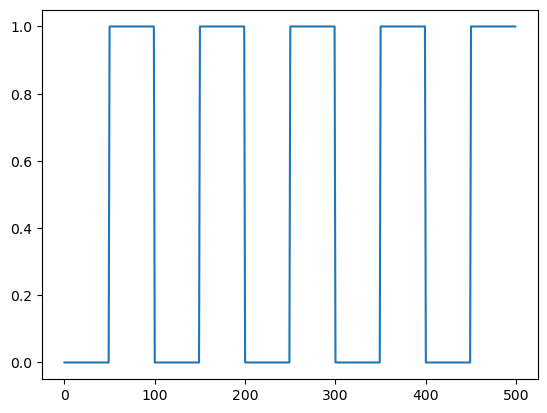

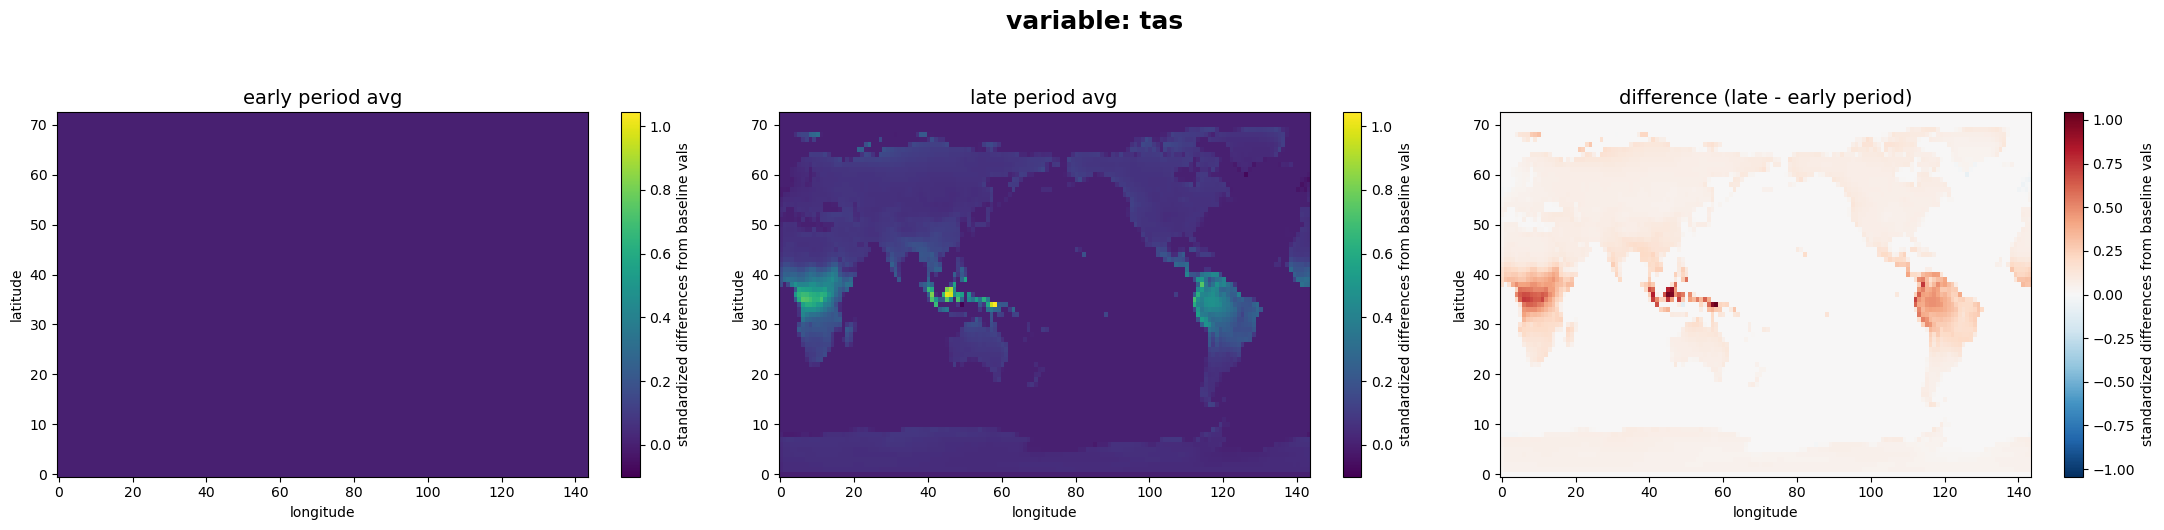

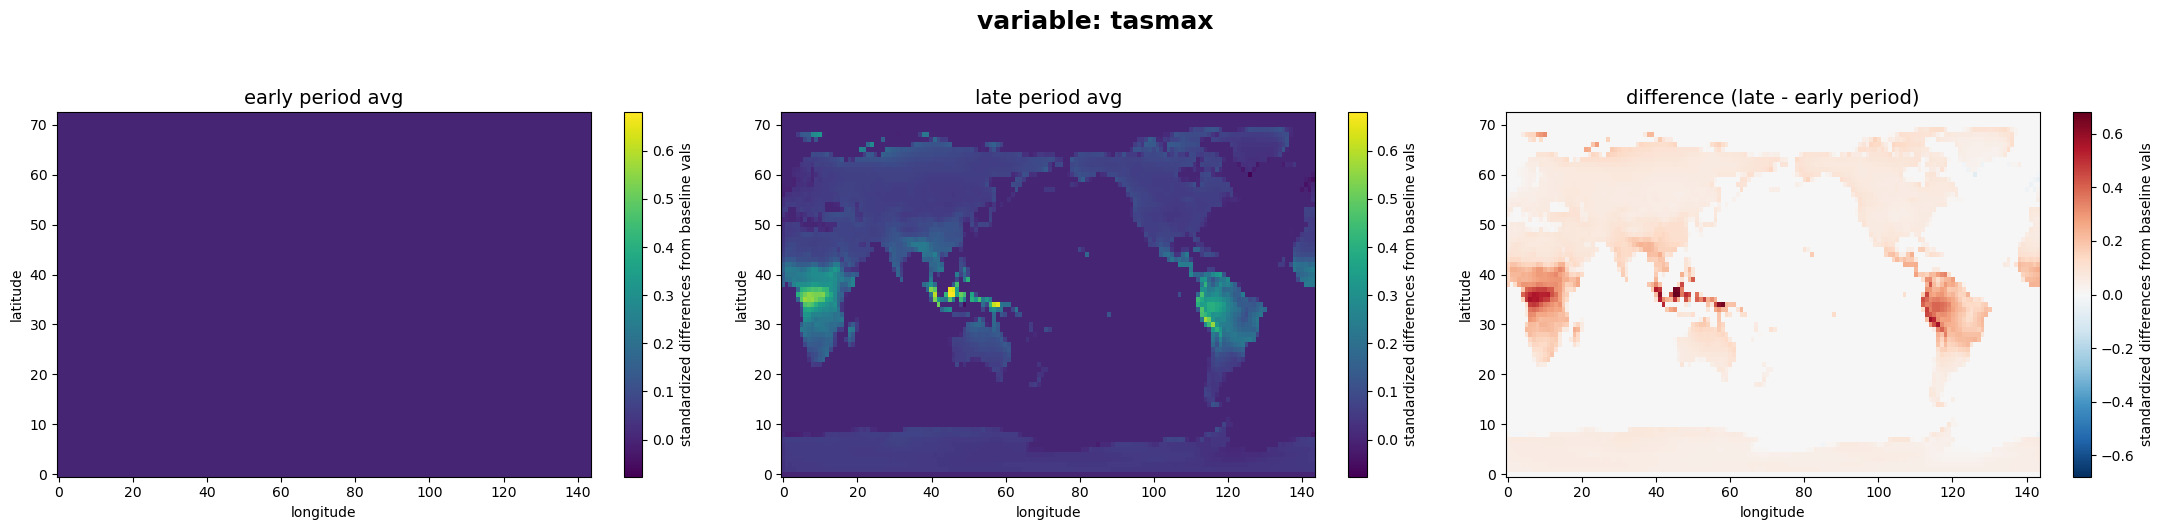

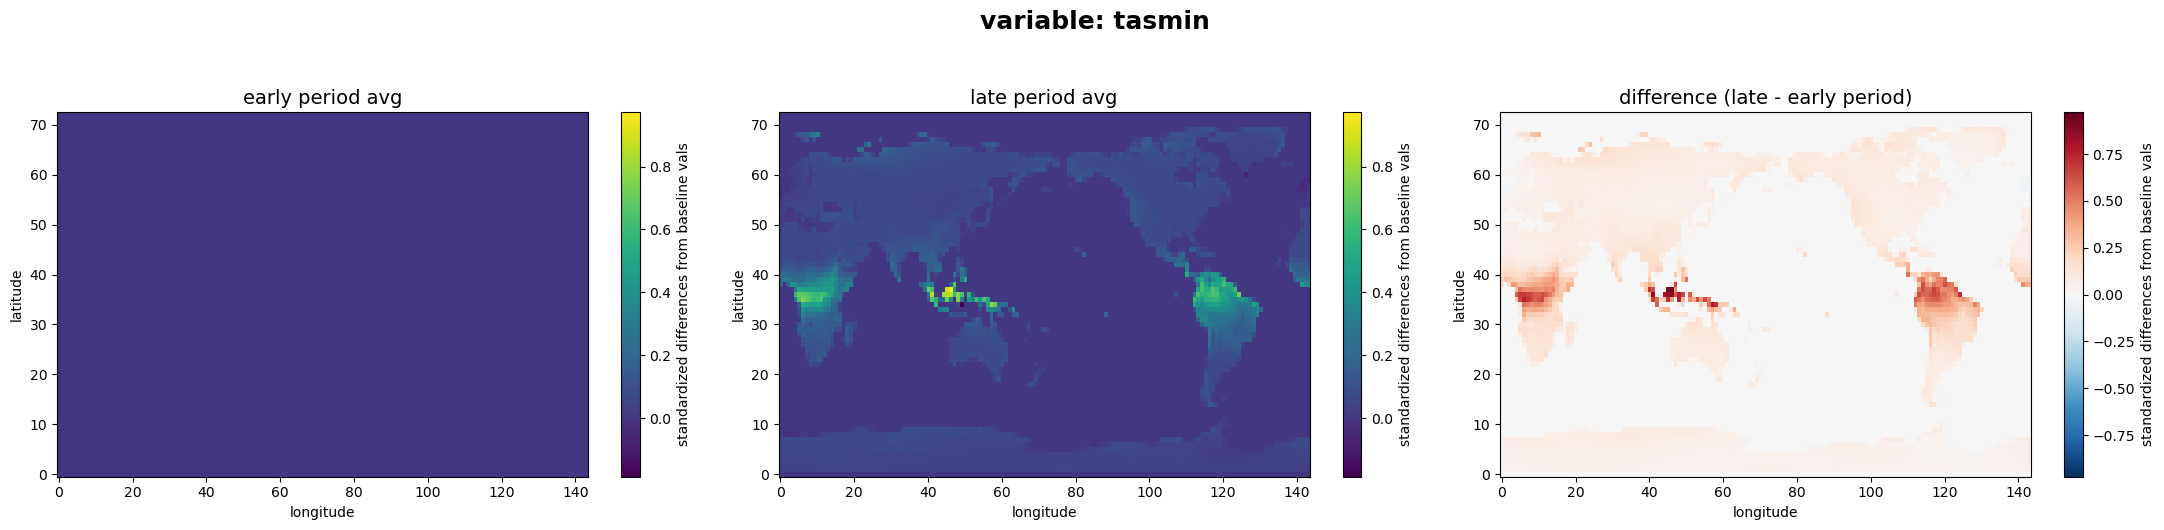

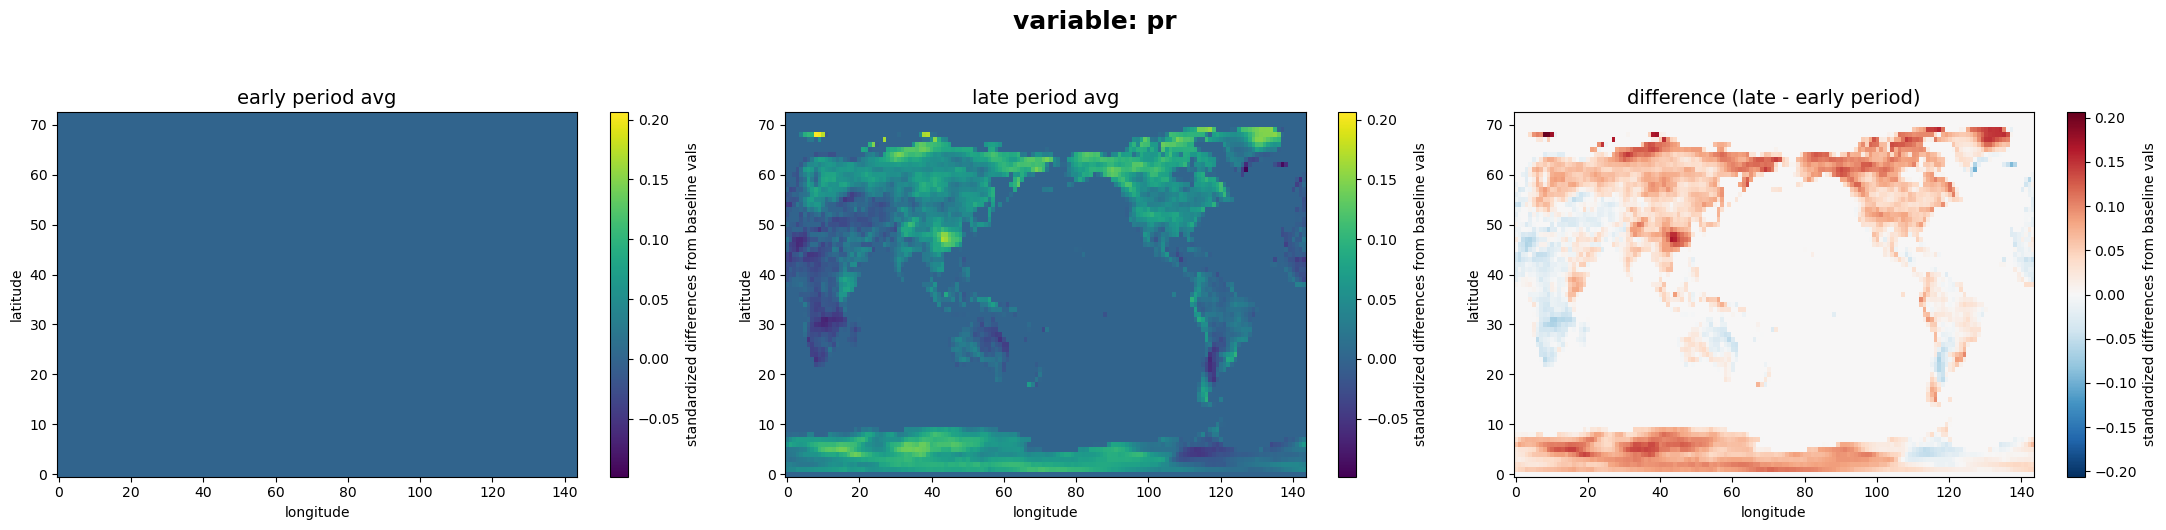

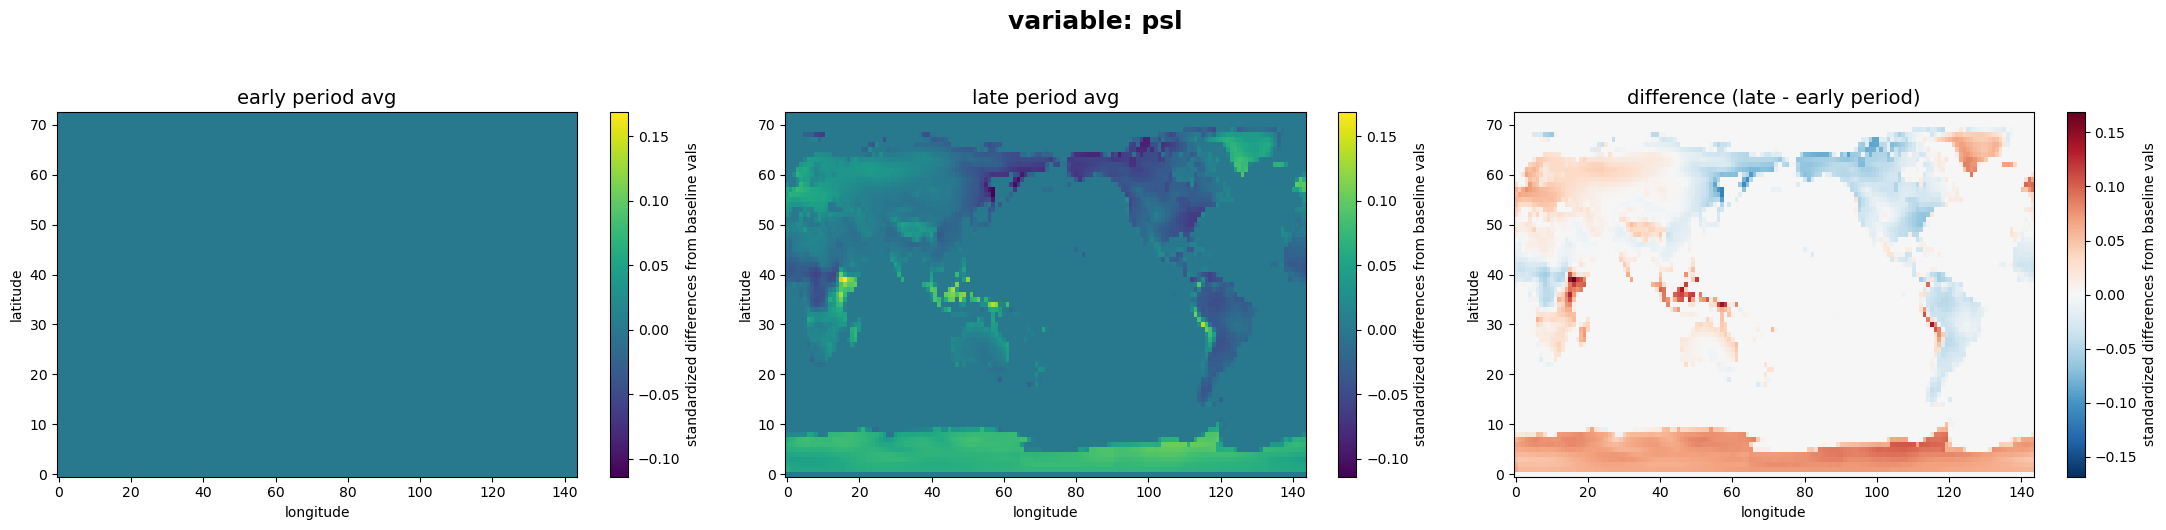

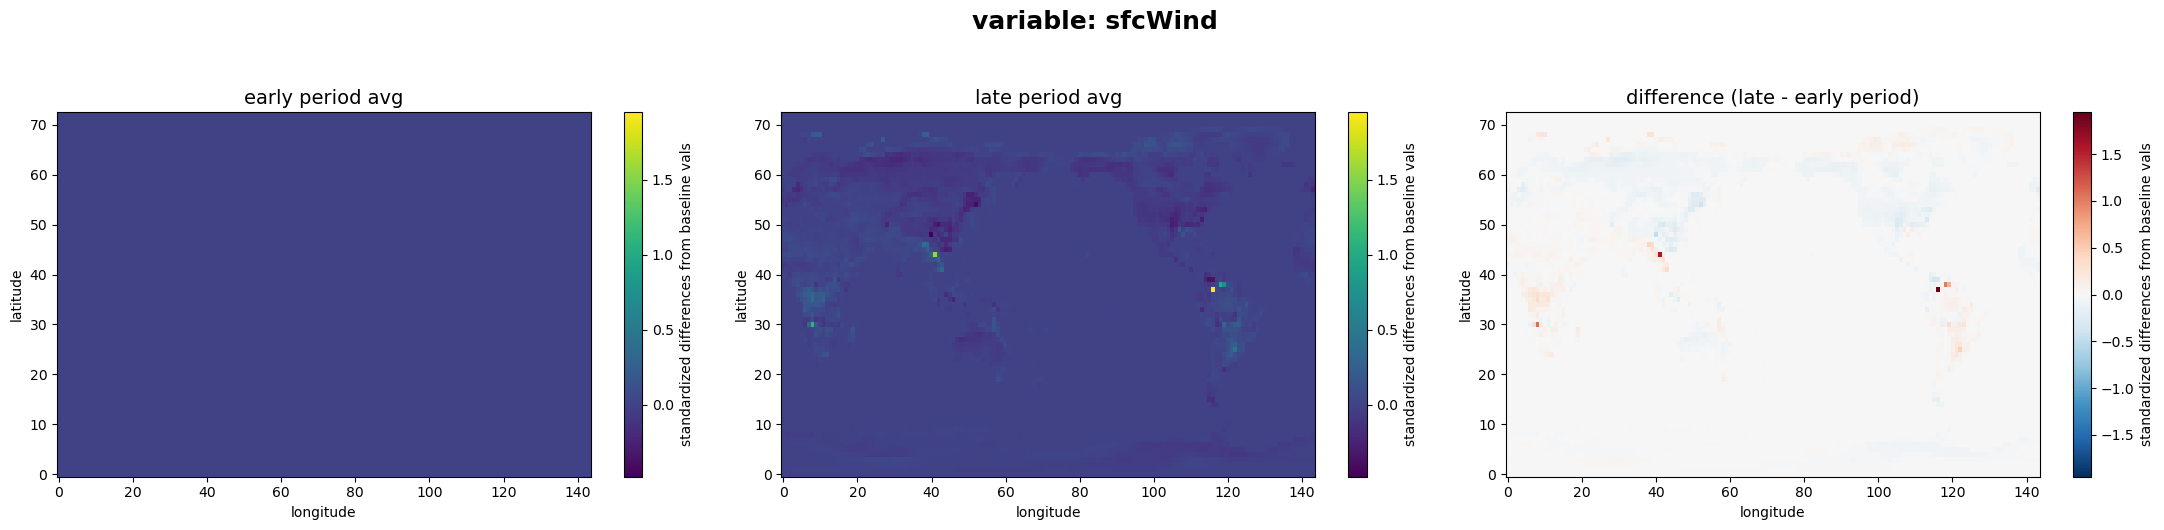

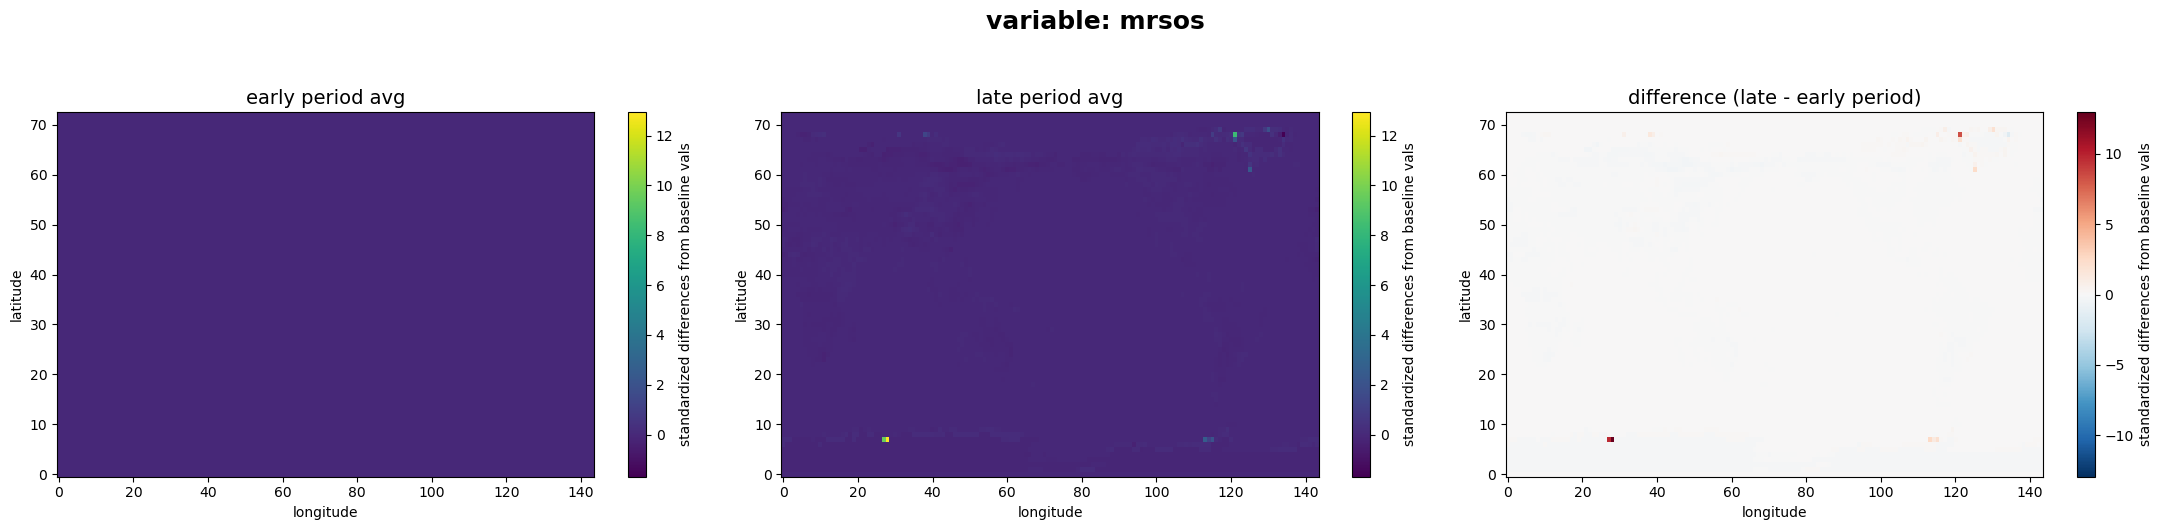

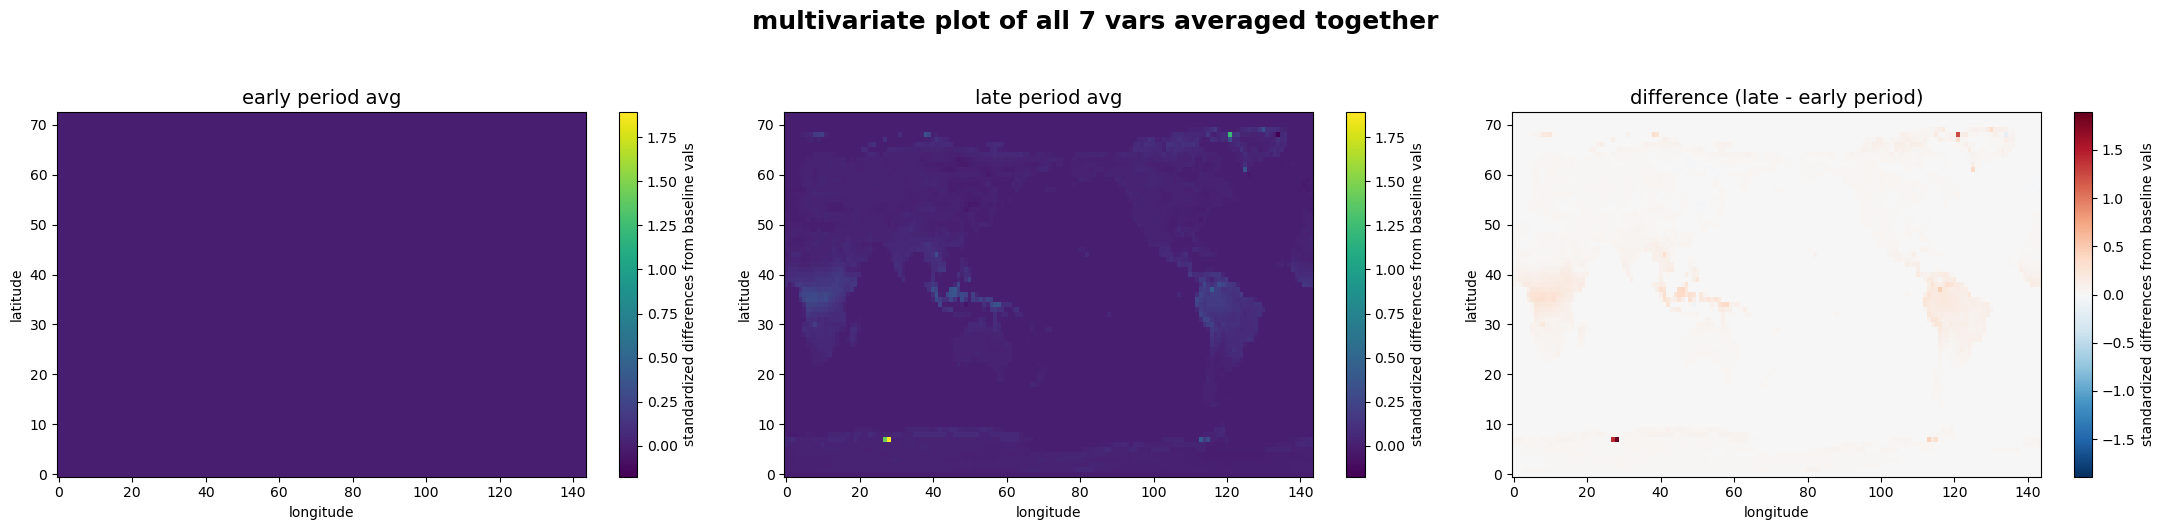

processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


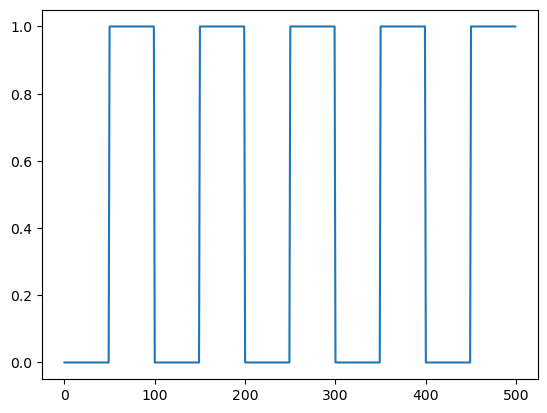

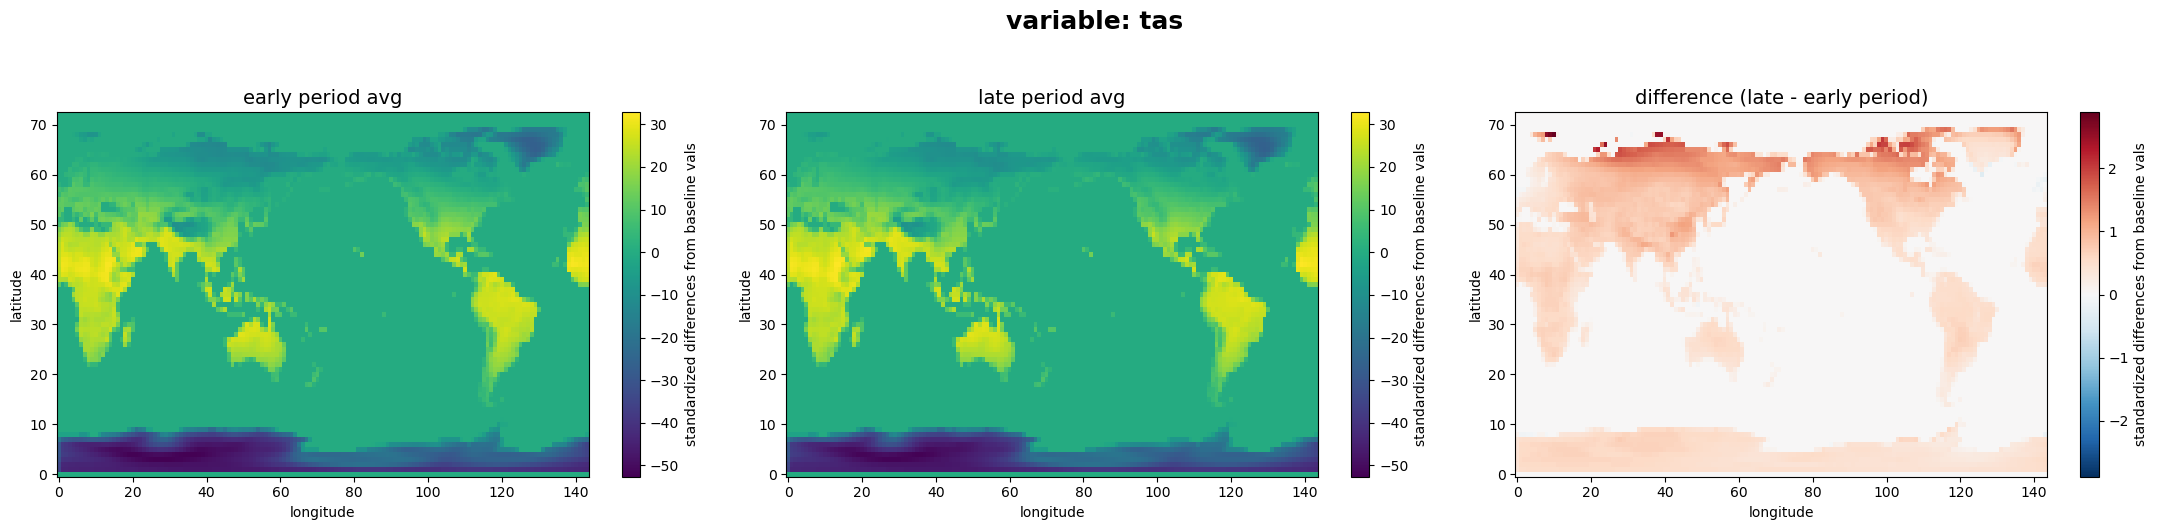

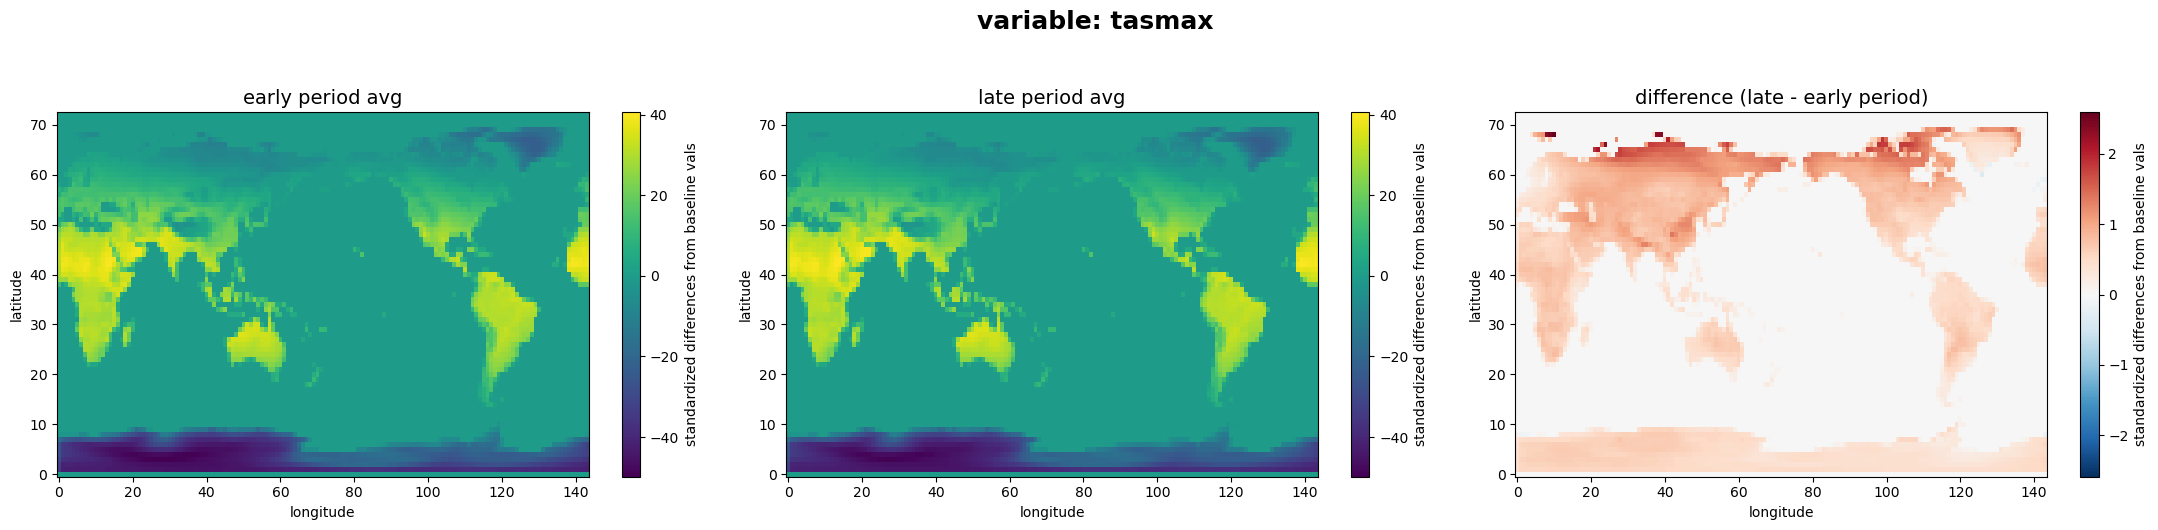

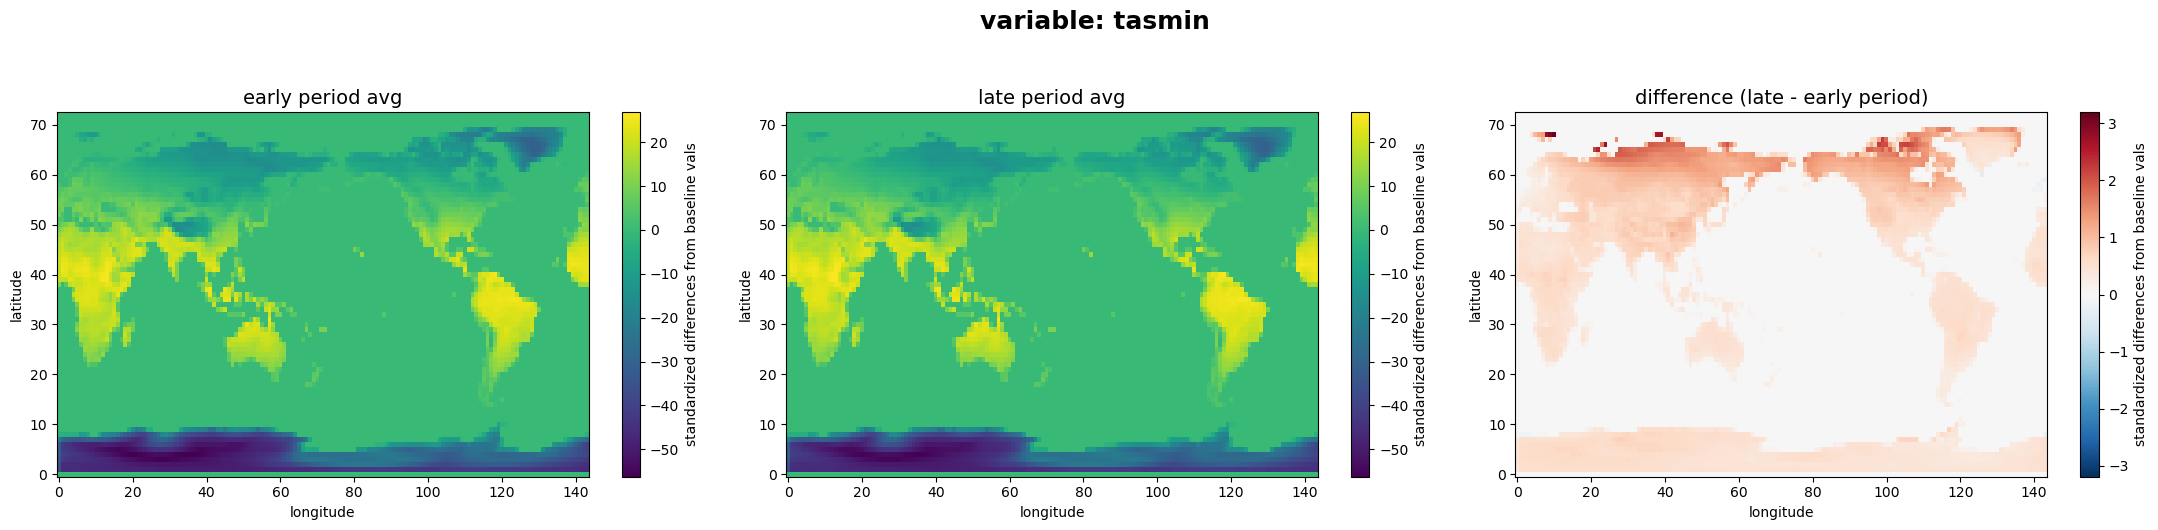

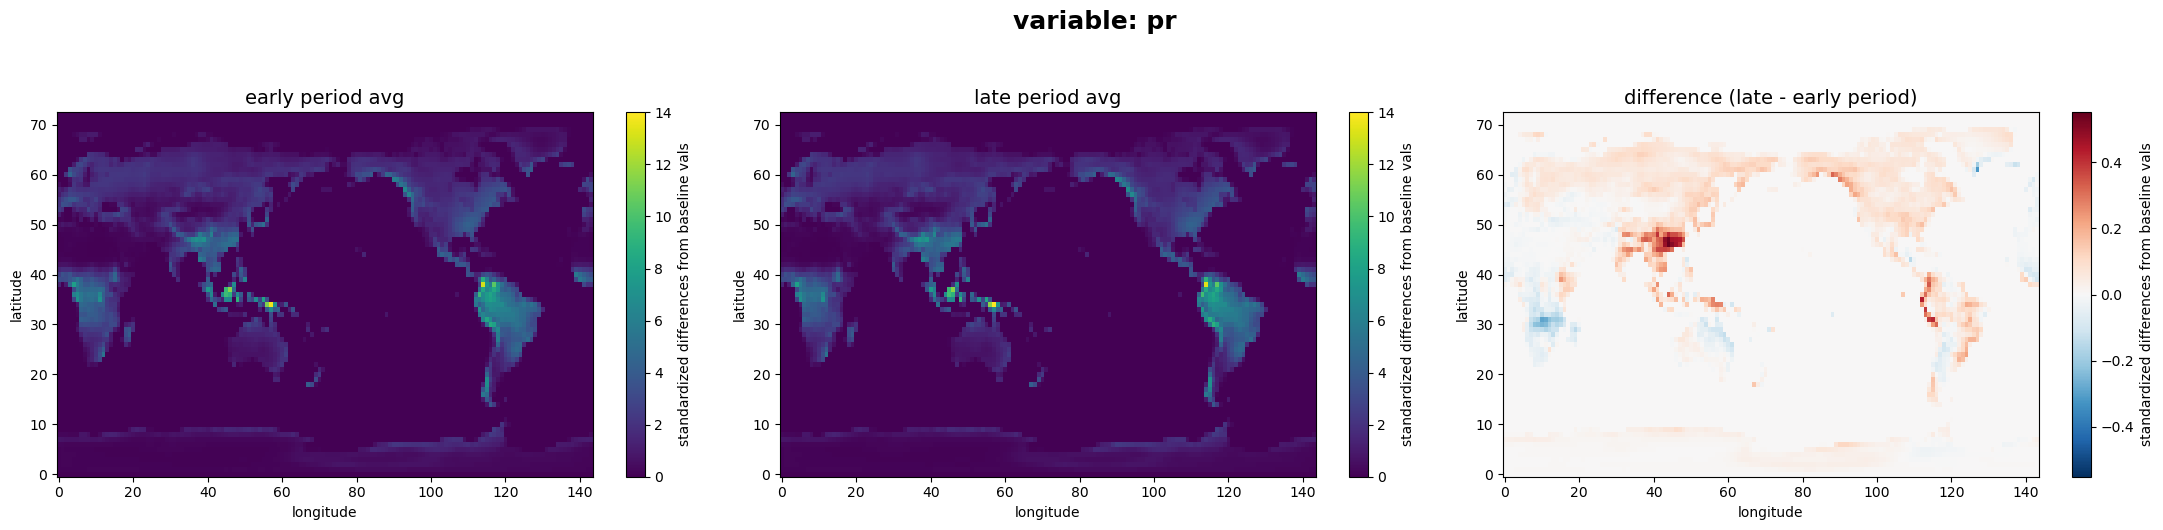

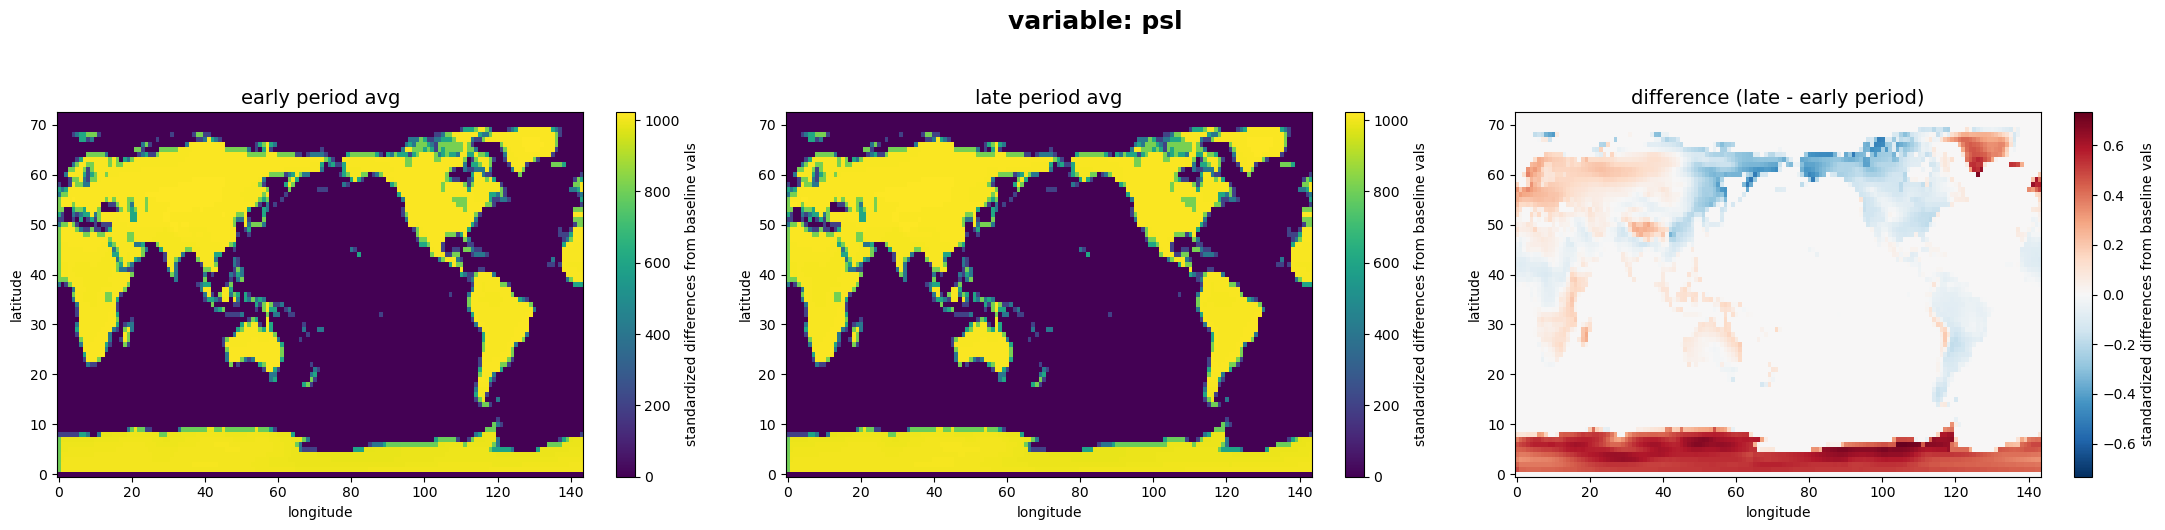

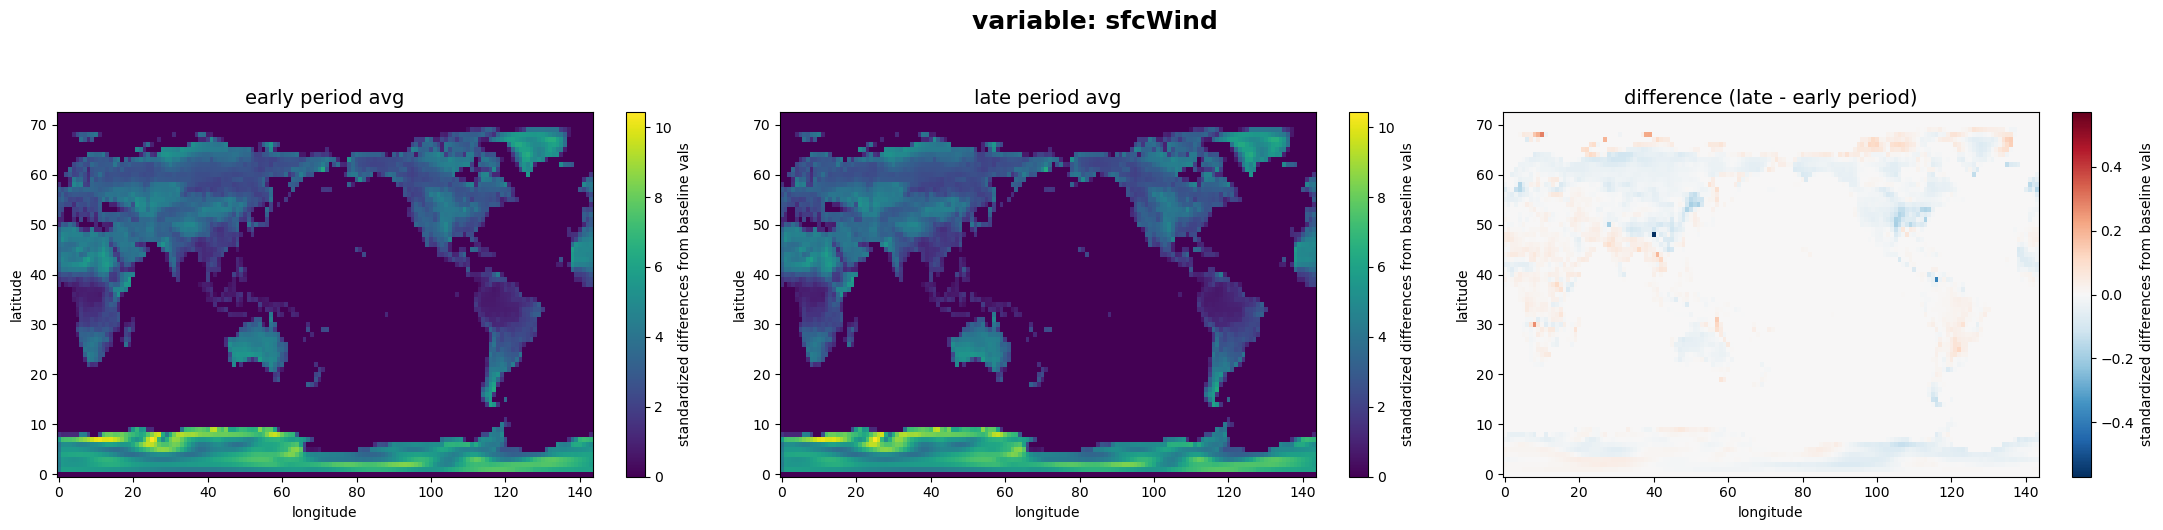

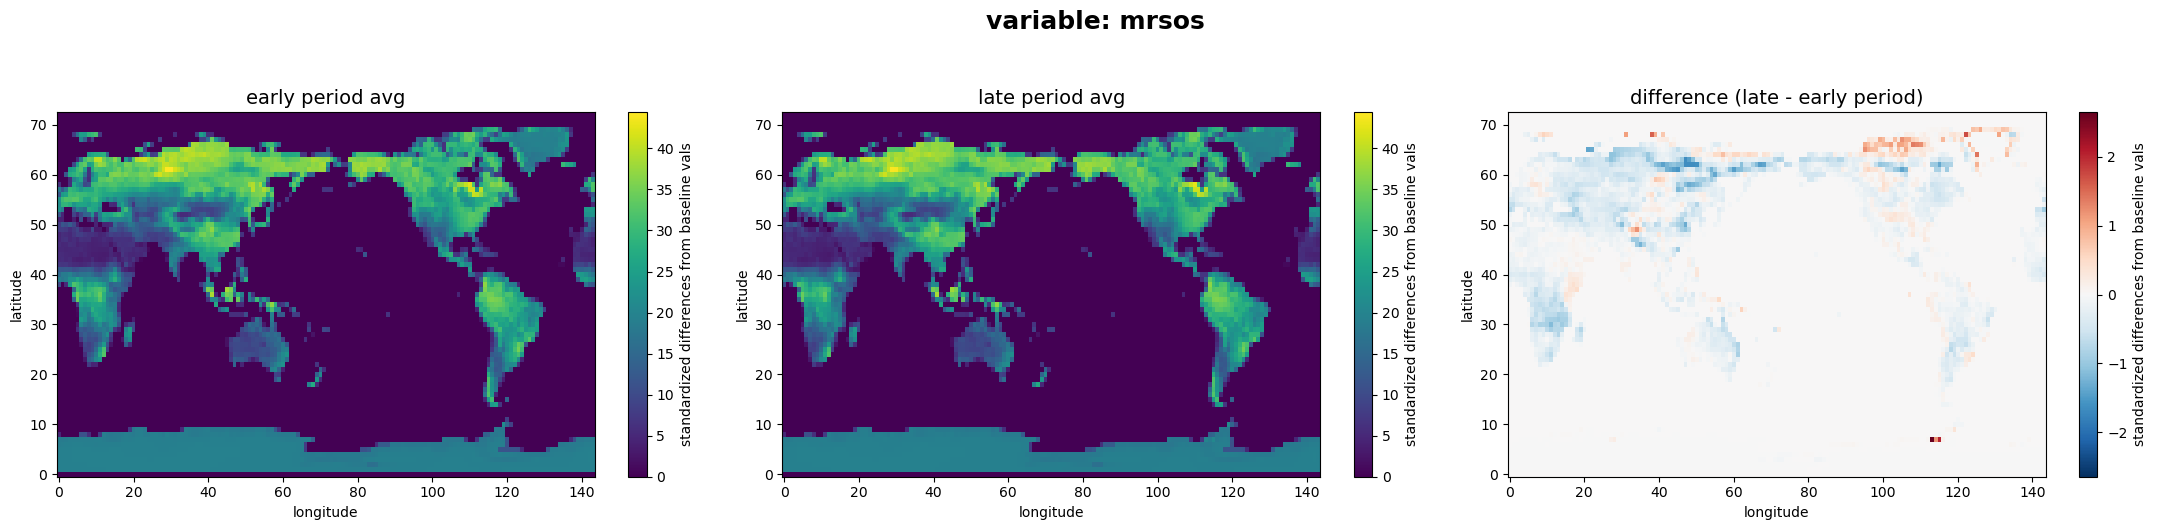

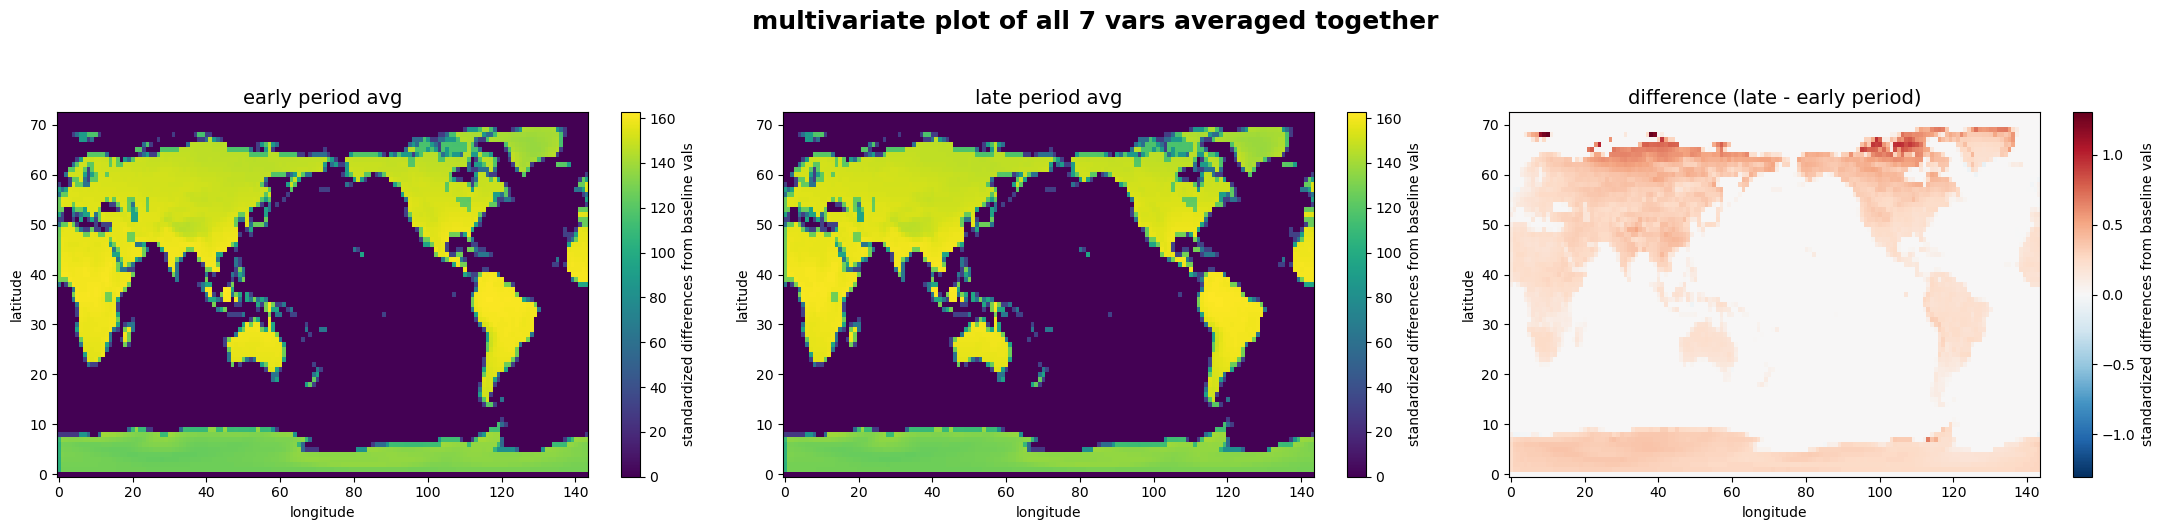

In [2]:
%run "data_prep_viz/prep/get_cnn_tensors.ipynb" 

In [3]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    return grads

In [4]:
def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    # 1. Ensure inputs and baseline are float32
    inputs = inputs.astype(np.float32)
    
    if baseline is None:
        # Fallback to zeros if no baseline provided
        baseline = np.zeros_like(inputs).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)
        # Ensure baseline has a leading dimension if it's a single mean map
        if baseline.ndim == inputs.ndim - 1:
            baseline = np.expand_dims(baseline, axis=0)

    # 2. Generate interpolation steps
    # We use np.linspace to create the scaling factors (alphas)
    alphas = np.linspace(0.0, 1.0, num_steps + 1)
    
    # 3. Compute Gradients along the path
    # We iterate through the interpolation path from baseline to input
    all_grads = []
    for alpha in alphas:
        # Interpolate: baseline + alpha * (input - baseline)
        step_input = baseline + alpha * (inputs - baseline)
        
        # Get gradients for this specific step
        grad = get_gradients(step_input, model, top_pred_idx=top_pred_idx)
        all_grads.append(grad)
    
    # 4. Convert to tensor for averaging
    # Shape: (num_steps + 1, batch, vars, lat, lon)
    all_grads = tf.convert_to_tensor(all_grads, dtype=tf.float32)

    # 5. Approximate the integral (Trapezoidal Rule)
    # Average the gradients of adjacent steps
    grads_at_step_ends = (all_grads[:-1] + all_grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads_at_step_ends, axis=0)

    # 6. Final IG calculation: (input - baseline) * average gradient
    integrated_grads = (inputs - baseline) * avg_grads.numpy()
    
    return integrated_grads

In [5]:
# sophie edit: said i didnt have some of the libs (feel like something didnt connect with the git but im scared)
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import netCDF4 as nc
import pandas as pd

In [6]:
def cnn_training(X_data, y_data, learning_rate=0.0001, epochs=200, batch_size=64):
    # prep indices
    n_samples = X_data.shape[0]
    indices = np.arange(n_samples) # [0, 1, 2, ..., N-1]

    X = np.transpose(X_data, (0, 2, 3, 1))  # (N, lat, lon, 7)
    y = y_data.astype(np.float32)           # (N, 1)

    
    # split test set (50 samples) 
        # passing indices to keep track of the indices that are goin in the set 
    X_rem, X_test, y_rem, y_test, idx_rem, test_indices = train_test_split(
        X, y, indices,
        test_size=50,
        stratify=y
    )

    # val split (from remaning 450 samples)
    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X_rem, y_rem, idx_rem,
        test_size=50,
        stratify=y_rem
    )

    
    lat, lon = X_train.shape[1], X_train.shape[2]
    model = models.Sequential([
        layers.Input(shape=(lat, lon, 7)),
        
        #  CNN block (64 filters) with two convs, then pool
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 32 kernels (conv + pool)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 16 kernels (conv only)
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),             
        layers.Dense(50, activation="relu"),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=2
    )

    # train model 
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Return everything needed for the large loop
    return model, X_train, y_train, X_test, y_test, test_indices

In [7]:

import xarray as xr

def run_climate_experiment(scenarios, early_starts, model_list, data_path):

    # initializing list to store results from each early/late period iteration
    all_results = []
    
    # looping thru each scenario (ssp119, ssp126)
    for scenario in scenarios:
        # for every early start year in early_starts list
        for early_start in early_starts:
            # make late period start years as 10 plus the early start year, going up to 2095
            late_starts = np.arange(early_start + 10, 2095, 10) 
            
            for late_start in late_starts:
                print(f"Processing: {scenario} | Early: {early_start} | Late: {late_start}")
                
                # prepping data for every early and late 10yr time period combo 
                X_data, y_data = get_cnn_tensors(
                    model_list, scenario, data_path, 
                    st_early=early_start, end_early=early_start+9, 
                    st_late=late_start, end_late=late_start+9
                )
                
                # training data 
                model, X_train, y_train, X_test, y_test, test_idx = cnn_training(X_data, y_data)
                
                # predicting
                preds = model.predict(X_test).flatten()

                # --- CALCULATE ACCURACY ---
                # Convert probabilities to binary 0 or 1 using 0.5 as threshold
                binary_preds = (preds > 0.5).astype(int)
                # Compare to y_test (flattened to match shapes)
                accuracy = np.mean(binary_preds == y_test.flatten())
                
                print(f"--> Iteration Accuracy: {accuracy:.2%}")
                
                # XAI STUFF: 
                # baseline is the mean of early period from training set
                early_idx = np.where(y_train == 0)[0]
                baseline = np.mean(X_train[early_idx], axis=0, keepdims=True)
                
                # getting late indices for X_test set 
                late_test_idx = np.where(y_test == 1)[0]
                ig_samples = X_test[late_test_idx]
                
                # integrated gradient calculation based on the early period baseline on the late period stuff 
                ig_output = get_integrated_gradients(ig_samples, model, baseline)
                if hasattr(ig_output, 'numpy'): 
                    ig_output = ig_output.numpy()
                
                
                late_test_idx = np.where(y_test == 1)[0]
                y_test_filtered = y_test[late_test_idx].flatten() # Convert (25, 1) to (25,)
                preds_filtered = preds[late_test_idx]

                # --- UPDATED SAVING LOGIC ---
                nc_filename = f"results_batches/res_{scenario}_{early_start}_{late_start}.nc"


                
                # Pass the FILTERED data (25 samples) instead of the full test set (50)
                save_iteration_netcdf(ig_output, y_test_filtered, preds_filtered, 
                                     scenario, early_start, late_start, nc_filename)
                
                final_accuracy = np.mean((preds > 0.5).astype(int) == y_test.flatten())
                print(f"final accuracy: {final_accuracy: .2%}")
                # For the CSV, it's fine to keep the summary of all 50 samples
                summary_row = pd.DataFrame([{
                    'scenario': scenario,
                    'early_yr': early_start,
                    'late_yr': late_start,
                    'mean_pred': np.mean(preds), 
                    'accuracy': final_accuracy 
                }])
                summary_row.to_csv("experiment_summary.csv", mode='a', 
                                   header=not os.path.exists("experiment_summary.csv"), 
                                   index=False)
                
                del ig_output, X_data, y_data, X_train, y_train, X_test
                
    # The return is now optional since everything is already on your hard drive!
    return None

import xarray as xr

def save_iteration_netcdf(ig_data, y_true, y_pred, scenario, early, late, filename):
    """
    Saves a single iteration's spatial heatmaps to NetCDF.
    Squeezes 4D tensors to 3D to ensure Xarray dimension compatibility.
    """
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    ds = xr.Dataset(
        data_vars={
            "ig_heatmaps": (("sample", "lat", "lon", "feature"), ig_data),
            "y_true": (("sample",), y_true),
            "y_pred": (("sample",), y_pred)
        },
        coords={
            "scenario": scenario,
            "early_yr": early,
            "late_yr": late
        }
    )
    ds.to_netcdf(filename)



In [8]:
results = run_climate_experiment(['ssp119', 'ssp126'], [2015, 2025, 2035, 2045, 2055, 2065, 2075], model_list, data_path) # Skip 2085, too late (cannot compare)
# 42 experiments, will take a while to run - suggested to run overnight
# Run this 6+ times to generate and quantify uncertainty

Processing: ssp119 | Early: 2015 | Late: 2025
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


2026-04-20 09:49:17.703474: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-20 09:49:17.703830: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-20 09:49:17.704359: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-20 09:49:17.704742: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-20 09:49:17.704798: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/200


...

processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 354ms/step - accuracy: 0.4925 - loss: 0.6933 - val_accuracy: 0.4200 - val_loss: 0.6939
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.4900 - loss: 0.6928 - val_accuracy: 0.4400 - val_loss: 0.6937
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 0.4875 - loss: 0.6928 - val_accuracy: 0.4600 - val_loss: 0.6941
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 275ms/step - accuracy: 0.4975 - loss: 0.6926 - val_accuracy: 0.4600 - val_loss: 0.6941
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - accuracy: 0.4925 - loss: 0.6926 - val_accuracy: 0.4600 - val_loss: 0.6941
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.5000 - loss: 0.6925 - val_accuracy: 0.4600 - val_loss: 0.6941
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - accuracy: 0.5025 - loss: 0.6924 - val_accuracy: 0.4600 - val_loss: 0.

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 377ms/step - accuracy: 0.5000 - loss: 0.6764 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.5000 - loss: 0.6736 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - accuracy: 0.5000 - loss: 0.6713 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.5000 - loss: 0.6703 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.5000 - loss: 0.6695 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.5000 - loss: 0.6693 - val_accuracy: 0.5000 - val_loss: 0.6970
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.5000 - loss: 0.6722 - val_accuracy: 0.5000 - val_loss: 0.

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_98845/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 523ms/step - accuracy: 0.5200 - loss: 0.7044 - val_accuracy: 0.4800 - val_loss: 0.6930
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.5175 - loss: 0.6971 - val_accuracy: 0.4800 - val_loss: 0.6931
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step - accuracy: 0.5325 - loss: 0.6962 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - accuracy: 0.5025 - loss: 0.6947 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.4925 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.4875 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.4950 - loss: 0.6906 - val_accuracy: 0.5000 - val_loss: 0